<a href="https://colab.research.google.com/github/TinoTonic/REDCap-SDTM-automation/blob/main/REDCap_SDTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Required Input Files

The notebook requires the following files:

- REDCap data dictionary in .csv

- SDTM controlled terminology (`SDTM Terminology 2026-03-27`)

- SDTMIG (`SDTMIG_v3.4.xlsx`)

If you want to generate an annotated CRF:

- Annotated CRF PDF generated by the external module `Annotated PDF`.



## 1. Installing and importing packages

In [ ]:
pip install thefuzz pymupdf

In [ ]:
import re
import pandas as pd
import pymupdf as fitz
from thefuzz import process
from pymupdf.utils import getColorList
from pymupdf.utils import getColorInfoList
il = getColorInfoList()
cl = getColorList()

## 2. Reading the Data Dictionary and SDTM files

The REDCap Data Dictionary is loaded from the `redcap_data.csv` file.

Columns that are not required for the SDTM mapping pipeline are removed from the original DataFrame to simplify subsequent processing.




In [ ]:
redcap_data = pd.read_csv("redcap_data.csv")

redcap_data = redcap_data.rename(columns={
    "Variable / Field Name": "Field Name",
    "Choices, Calculations, OR Slider Labels": "Choices"
     })
redcap_data = redcap_data.drop(columns=[
    'Question Number (surveys only)',
    'Section Header',
    'Field Note',
    'Text Validation Min',
    'Text Validation Max',
    'Branching Logic (Show field only if...)',
    'Custom Alignment',
    'Question Number (surveys only)',
    'Matrix Group Name',
    'Matrix Ranking?'
    ])

terminology = pd.read_excel("SDTM Terminology.xls", sheet_name="SDTM Terminology 2026-03-27")

sdtm_variables = pd.read_excel("SDTMIG_v3.4.xlsx", sheet_name = "Variables")

sdtm_dataset = pd.read_excel("SDTMIG_v3.4.xlsx", sheet_name = "Datasets")


## 3. Reading REDCap Field Annotations

The code below uses two regular expressions to parse metadata from REDCap.

- **`sdtm_pattern`** parses SDTM annotations written as:
  - `SDTM:IT.domain.variable.testcd;`
  - Captured groups:
    - `domain`
    - `variable`
    - `testcd` (optional)

- `[.,:]` allows `.`, `,`, or `:` as separators to tolerate minor typing inconsistencies in the annotations.


- **`submission_pattern`** parses REDCap submission options from the Data Dictionary, such as:
  - `Y, Yes | N, No`
  - Captured groups:
    - `REDCap_Value` = `Y` | `N`
    - `REDCap_Term` = `Yes` | `No`




In [ ]:
redcap_values = []
domains = []

sdtm_pattern = r"SDTM[.,:]IT[.,:](?P<DOMAIN>\w+)\.(?P<SDTM_VARIABLE>\w+)(?:\.(?P<TESTCD>\w+))?[;.:]?"
submission_pattern = r"\s*(?P<REDCap_Value>[^,|]+)\s*,\s*(?P<REDCap_Term>[^|]+)"

for _, row in redcap_data.iterrows():
    field_annotation = str(row["Field Annotation"]).strip()
    field_name = str(row["Field Name"]).strip()
    values = str(row["Choices"]).strip()
    field_type = str(row["Field Type"]).strip()
    if field_type == "sql":
        continue
    if field_name.startswith("desc_"):
        redcap_data.at[_, "Field Label"] = ""
    match = re.search(sdtm_pattern, field_annotation)
    if match:
        redcap_data.at[_, "DOMAIN"] = match.group("DOMAIN")
        redcap_data.at[_, "SDTM VARIABLE"] = match.group("SDTM_VARIABLE")
        redcap_data.at[_, "TESTCD"] = match.group("TESTCD")
    else:
        redcap_data.at[_, "DOMAIN"] = ""
        redcap_data.at[_, "SDTM VARIABLE"] = ""
        redcap_data.at[_, "TESTCD"] = ""
    if redcap_data.at[_, "DOMAIN"] != "":
        domains.append({
        "Domain": redcap_data.at[_, "DOMAIN"]
        })

    for match in re.finditer(submission_pattern, values):
          redcap_values.append({
              "Field Name": field_name,
              "REDCap Value": match.group("REDCap_Value"),
              "REDCap Term": match.group("REDCap_Term").strip()
          })

Variable_Metadata = redcap_data.copy()

REDCap_Values = pd.DataFrame(redcap_values)

## 4. Creating the Dataset Metadata File

This step creates a separate Excel file containing the **`Datasets`** worksheet.

The worksheet lists all SDTM domains identified in the CRF, together with their corresponding class, description, and structure.

- **`supp_list`** identifies all SUPPQUAL domains present in the CRF and stores them in a separate list.

- **`datasetmetadata`** merges the identified domains (generated in the previous code cell) with the **SDTMIG v3.4** metadata to retrieve the corresponding class, description, and structure.


Since **SDTMIG v3.4** does not include metadata for all **SUPP--** domains, the script uses **`supp_list`** to assign the default SUPPQUAL structure to those datasets.



In [ ]:
domains = pd.DataFrame(domains)
domains = domains.drop_duplicates()
supp_list = [dom[-2:] for dom in domains["Domain"] if dom.startswith("SUPP")]

datasetmetadata = (domains.merge(
        sdtm_dataset,
        left_on="Domain",
        right_on="Dataset Name",
        how="inner"
        )
        [["Dataset Name","Class","Dataset Label","Structure"]]
)

supp_rows_data = []

for dom in supp_list:
    new_row = {
        "Dataset Name": f"SUPP{dom}",
        "Class": "Relationship",
        "Dataset Label": f"Supplemental Qualifiers for {dom}",
        "Structure": "One record per IDVAR, IDVARVAL, and QNAM value per subject",
        }
    supp_rows_data.append(new_row)

df_supp_metadata = pd.DataFrame(supp_rows_data)

Dataset_Metadata = pd.concat([datasetmetadata, df_supp_metadata], ignore_index=True)

## 4. Reading Files

The data generated in the previous steps is loaded into working Data Frames.

- **`mapping`** contains the variable metadata extracted from the REDCap Data Dictionary.
- **`codelist`** contains the REDCap submission values and their corresponding terms.

Missing values are replaced with empty strings to simplify subsequent processing.



In [ ]:
mapping = Variable_Metadata.copy()
mapping.fillna("")

codelist = REDCap_Values.copy()
codelist.fillna("")

## 5. Filtering and Generating values of Mapped Variables

This step creates a separate sheet that merges REDCap Submission Values and SDTM Variables of every field.

- Variables without an SDTM mapping are removed.
- The SDTM variable **`RACE`** is renamed to **`RACEC`** to match the SDTM standard.
- The filtered variable metadata is merged with the REDCap submission values using the REDCap field name.

The resulting table contains, for each mapped variable, its SDTM variable name, optional `TESTCD`, and the corresponding REDCap values and terms. This table is used to generate the SDTM codelists.


In [ ]:
mapping["SDTM VARIABLE"] = (mapping["SDTM VARIABLE"].astype(str).str.strip())

mapping_filtered = mapping[(mapping["SDTM VARIABLE"] != "") & (mapping["SDTM VARIABLE"] != "nan")]

mapping_filtered = pd.DataFrame(mapping_filtered)

mapping_filtered.loc[mapping_filtered["SDTM VARIABLE"] == "RACE", "SDTM VARIABLE"] = "RACEC"

Codelists = (mapping_filtered.merge(
        codelist,
        left_on="Field Name",
        right_on="Field Name",
        how="inner"
        )
        [["Field Name","SDTM VARIABLE","TESTCD","REDCap Term","REDCap Value"]]
)

CRF_SDTM_Variables = Codelists.to_dict("records")
CRF_SDTM_Variables = pd.DataFrame(CRF_SDTM_Variables)

## 6. Linking Mapped Variables to CDISC Codelists

This step links each mapped SDTM variable to its corresponding CDISC controlled terminology.

- The script searches the SDTM variable metadata to identify the **CDISC CT Codelist Code** associated with each mapped variable.
- Using the codelist code, it retrieves all controlled terminology terms from the CDISC terminology file.
- For variables that are themselves represented as CDISC submission values (e.g., `RACE` or `RACEC`), the script also identifies and links their corresponding codelists.
- Duplicate entries are removed to ensure that each variable -> codelist relationship is stored only once.

The resulting **`Codelist_Codes`** Data Frame contains, for each mapped variable, its associated CDISC codelist, terminology codes, submission values, and preferred terms. This information is used in the subsequent generation of SDTM codelists.


In [ ]:
link = {}
linked_by_code = []

for _, row in mapping.iterrows():
    field_name = str(row["Field Name"]).strip()
    domain = str(row["DOMAIN"]).strip()
    variable = str(row["SDTM VARIABLE"]).strip()
    testcd = str(row["TESTCD"]).strip()
    if not variable:
        continue

    for _, row in sdtm_variables.iterrows():
        var = str(row["Variable Name"]).strip()
        if var == variable:
            codelistcode = str(row["CDISC CT Codelist Code(s)"]).strip()
            if codelistcode == "nan":
                continue
            link[variable] = {"Variable": variable,"Codelist Code": codelistcode}

df = pd.DataFrame(link).T

for _, df_row in df.iterrows():
    variable = df_row["Variable"]
    dfclcode = df_row["Codelist Code"]

    for _, term_row in terminology.iterrows():
        clcode = str(term_row["Codelist Code"]).strip()
        subval = str(term_row["CDISC Submission Value"]).strip()

        if clcode == dfclcode:
            linked_by_code.append({
                "Variable": variable,
                "Codelist Name": str(term_row["Codelist Name"]).strip(),
                "Codelist Code": dfclcode,
                "Codes": str(term_row["Code"]).strip(),
                "Submission Value": str(term_row["CDISC Submission Value"]).strip(),
                "NCI Pref. Term": str(term_row["NCI Preferred Term"]).strip()
            })
        if subval == variable or subval == f"{variable}C":
            code = str(term_row["Code"]).strip()
            saved_vars = [item["Variable"] for item in linked_by_code]
            for _, term_row in terminology.iterrows():
                if code == str(term_row["Codelist Code"]).strip():
                    if subval not in saved_vars:
                        linked_by_code.append({
                            "Variable": subval,
                            "Codelist Name": str(term_row["Codelist Name"]).strip(),
                            "Codelist Code": str(term_row["Codelist Code"]).strip(),
                            "Codes": str(term_row["Code"]).strip(),
                            "Submission Value": str(term_row["CDISC Submission Value"]).strip(),
                            "NCI Pref. Term": str(term_row["NCI Preferred Term"]).strip()
                        })

Codelist_Codes = pd.DataFrame(linked_by_code)
Codelist_Codes = Codelist_Codes.drop_duplicates()

## 7. Generating Study Specific Controlled Terminology Translation

This step generates the study specific controlled terminology by mapping REDCap terms to their corresponding SDTM controlled terminology values.

- The available SDTM submission values are extracted from the previously generated **`Codelist_Codes`** DataFrame.
- A fuzzy matching approach is used to identify the closest SDTM submission value for each REDCap term. This allows minor differences in wording between the CRF and CDISC terminology to be matched.
- REDCap submission `**terms** are used for matching instead of REDCap values. This is because REDCap values are often stored as coded responses, for example:

  `1, Black | 2, White | 3, Asian`

  Matching based on the terms allows the CRF labels to be updated to better align with CDISC preferred terminology without affecting the stored values or existing branching logic.


- Only matches above the defined similarity threshold are accepted.
- Specific SDTM variable names are standardized to ensure consistency with SDTM controlled terminology:
  - `QVAL` variables are renamed using their corresponding `TESTCD`.
  - `RACE` is mapped to `RACEC`.
  - `ETHNIC` and `CETHNIC` are mapped to `ETHNICC`.

The matched REDCap terms are then merged with the CDISC codelist metadata to create the **`Controlled_Terminology`** DataFrame.

The final output contains:
- REDCap field information
- SDTM variable and test code
- CDISC codelist name and code
- Controlled terminology codes
- REDCap values and terms
- Corresponding CDISC submission values and NCI preferred terms

Duplicate mappings are removed to ensure that each SDTM variable, test code, codelist, and terminology code combination is uniquely represented.


In [ ]:
SDTM_Values = Codelist_Codes["Submission Value"].astype(str).tolist()

def get_fuzz_match(text, choices_list, threshold=50):
    match, score = process.extractOne(str(text), choices_list)
    if score >= threshold:
        return match
    else:
        return None

CRF_SDTM_Variables["Temp"] = CRF_SDTM_Variables["REDCap Term"].apply(
    lambda x: get_fuzz_match(x, SDTM_Values, threshold=70)
)

CRF_SDTM_Variables.loc[CRF_SDTM_Variables["SDTM VARIABLE"] == "QVAL", "SDTM VARIABLE"] = CRF_SDTM_Variables["TESTCD"]
CRF_SDTM_Variables.loc[CRF_SDTM_Variables["SDTM VARIABLE"] == "RACE", "SDTM VARIABLE"] = "RACEC"
CRF_SDTM_Variables.loc[CRF_SDTM_Variables["SDTM VARIABLE"] == "ETHNIC", "SDTM VARIABLE"] = "ETHNICC"
CRF_SDTM_Variables.loc[CRF_SDTM_Variables["SDTM VARIABLE"] == "CETHNIC", "SDTM VARIABLE"] = "ETHNICC"

Controlled_Terminology = (
    CRF_SDTM_Variables.merge(
        Codelist_Codes,
        left_on=["SDTM VARIABLE","Temp"],
        right_on=["Variable","Submission Value"],
        how="right"
    )
    [["Field Name","SDTM VARIABLE","TESTCD","Codelist Name","Codelist Code", "Codes", "REDCap Value", "REDCap Term", "Submission Value", "NCI Pref. Term"]]
)

Controlled_Terminology.loc[Controlled_Terminology["SDTM VARIABLE"] == "RACEC", "SDTM VARIABLE"] = "RACE"

CRF_SDTM_Variables.drop(columns=["Temp"], inplace=True)

Controlled_Terminology = Controlled_Terminology.drop_duplicates(subset=["SDTM VARIABLE", "TESTCD", "Codelist Code", "Codes"])

## 8. Output Files

In [ ]:
with pd.ExcelWriter("REDCap Mapping Spec.xlsx", engine="openpyxl") as writer:

    Dataset_Metadata.to_excel(writer, sheet_name="Dataset Metadata", index=False)

    Variable_Metadata.to_excel(writer, sheet_name="Variable Metadata", index=False)

    REDCap_Values.to_excel(writer, sheet_name="REDCap Values", index=False)

    Codelist_Codes.to_excel(writer, sheet_name="Variables Codelists", index=False)

    Controlled_Terminology.to_excel(writer, sheet_name="Controlled Terminology", index=False)

## **Annotated CRF pipeline**



##1. Reading files

In [ ]:
mapping = pd.read_excel('REDCap Mapping Spec.xlsx', sheet_name='Variable Metadata')
mapping = mapping.fillna("")

dataset = pd.read_excel('REDCap Mapping Spec.xlsx', sheet_name='Dataset Metadata')
dataset = dataset[["Dataset Name", "Dataset Label"]]
dataset = dataset[~dataset["Dataset Name"].str.startswith("SUPP")]
dataset = dataset.fillna("")

crf = "AnnotatedPDF.pdf" # Annotated PDF from REDCap

acrf = "ACRF.pdf"

##2. Choosing domain collors



The variable `il` can be used to access the `Color Information List` from `PyMuPDF`.

You can explore all available colors in the `PyMuPDF Color Database`.

https://pymupdf.readthedocs.io/en/latest/colors.html#color-database

`RGB Normalization`: To add new colors to the `DOMAIN_COLORS` list, remember to divide the RGB values by `255` first (converting them to a 0.0 to 1.0 scale).

In [ ]:
il

In [ ]:
DEFAULT_COLOR = (0.48, 0.8, 0.48) # Light green

DOMAIN_COLORS = {
    "DM": (0.48, 0.80, 0.48),   # Light green
    "SUPPDM": (0.48, 0.80, 0.48),
    "AE": (0.98, 0.60, 0.20),   # Orange
    "SUPPAE": (0.98, 0.60, 0.20),
    "CM": (0.42, 0.71, 0.91),   # Blue
    "SUPPCM": (0.42, 0.71, 0.91),
    "MH": (0.85, 0.55, 0.85),   # Purple
    "SUPPMH": (0.85, 0.55, 0.85),
    "LB": (0.95, 0.85, 0.30),   # Yellow
    "SUPPLB": (0.95, 0.85, 0.30),
    "CE": (0.30, 0.85, 0.85),   # Light Blue
    "SUPPCE": (0.30, 0.85, 0.85),
    "FA": (0.90, 0.45, 0.45),   # Red
    "SUPPFA": (0.90, 0.45, 0.45),
    "DS": (1, 0.75, 0.79),      # Pink
    "SUPPDS": (1, 0.75, 0.79),
    "QS": (1,0.64,0.05),        # Orange
    "SUPPQS":(1,0.64,0.05)
}

##3. Variable Annotations Generation

- "Field Name" is the REDCap variable name. The script searches line by line and attaches every SDTM annotation under its related REDCap variable name.

- The script uses `PyMuPDF` to search for the specific field name of every mapped variable

- The script looks for  `("{"f"[{field_name}]")` because of the annotated PDF syntax. 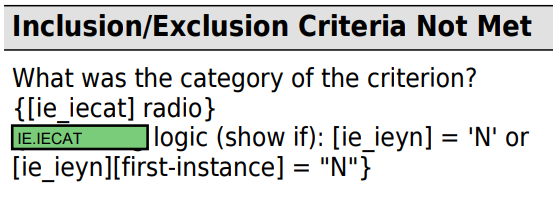

- You can change the search for to `"[field_name]"` in case you want to also annotate branching logic variables.

- `PyMuPDF` is used to create the text boxes, choose their size and color depending on the domain, variable and testcd.

In [ ]:
doc = fitz.open(crf)

for _, row in mapping.iterrows():
    field_name = str(row["Field Name"]).strip()
    domain = str(row["DOMAIN"]).strip()
    variable = str(row["SDTM VARIABLE"]).strip()
    testcd = str(row["TESTCD"]).strip()

    if not field_name:
        continue

    for page in doc:
        matches = page.search_for("{"f"[{field_name}]")
        for rect in matches:
            if domain.startswith("SUPP"):
                box = fitz.Rect(rect.x0 - 20,rect.y1 + 1,rect.x0 + 60,rect.y1 + 10)
            elif testcd:
                box = fitz.Rect(rect.x0 - 20,rect.y1 + 1,rect.x0 + 110,rect.y1 + 10)
            else:
                box = fitz.Rect(rect.x0,rect.y1 + 1,rect.x0 + 52,rect.y1 + 10)

            if not domain:
                fieldcolor = (0.85, 0.85, 0.85)
            else:
                fieldcolor = DOMAIN_COLORS.get(domain, DEFAULT_COLOR)

            page.draw_rect(box, color=(0, 0, 0), fill = fieldcolor, overlay=True)

            if domain and variable and testcd:
                if domain.startswith("SUPP"):
                    page.insert_text((box.x0 + 2, box.y1 - 2),f"{testcd} in {domain}",fontsize=6,color=(0, 0, 0),overlay=True)
                else:
                    page.insert_text((box.x0 + 2, box.y1 - 2),f'{variable} where {domain}TESTCD = "{testcd}"',fontsize=6,color=(0, 0, 0),overlay=True)

            elif domain and variable:
                page.insert_text((box.x0 + 2, box.y1 - 2),f"{domain}.{variable}",fontsize=6,color=(0, 0, 0),overlay=True)
            else:
                page.insert_text((box.x0 + 2, box.y1 - 2),"NOT SUBMITTED",fontsize=6,color=(0, 0, 0),overlay=True)

doc.save(acrf)

##3.1 Page Title Generation

***This logic is way more confusing than it should be, but it works.***
#

- Form Name is normalized and two new column are created: **Form + Domain** and **Normalized Form Name**.

"FORM.DOMAIN" is then used to drop duplicated lines, and allow us to get only unique domains for every specific page.

- Domains are grouped by ", " and put into a dictionary.

- The "search for" logic is then repeated, `page.search_for(f"{formname}")` looks for the normalized "Form Name" and then adds its specific domains with the exception of "SUPP__" that does not need to be added.

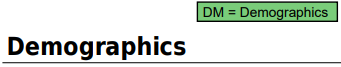

In [ ]:
for i in mapping.index:
    domain = str(mapping.loc[i,"DOMAIN"])
    form = str(mapping.loc[i,"Form Name"])

    if domain and form:
        form = str(form).title().replace("_", " ").strip()
        formdomain = f"{form} = ({domain})"
        mapping.loc[i,"FORM.DOMAIN"] = formdomain
        mapping.loc[i,"FORM"] = form

mapping_filtered = mapping.drop_duplicates(subset=["FORM.DOMAIN"])

alldomains = (mapping_filtered.groupby("FORM")["DOMAIN"].apply(lambda x: ", ".join(x)).to_dict())

for formname, dominios in alldomains.items():

    for page in doc:
        matches = page.search_for(f"{formname}")

        for rect in matches:
            if rect.y0 > 40:
                continue
            if rect.height<15:
                continue

            height = 14
            distance = 6
            x0box = rect.x1 + 8
            y0box = (rect.y0 + (rect.height - height) / 2) - 25
            y1box = y0box + height

            for dom in dominios.split(", "):
                if dom.startswith("SUPP"):
                    continue

                domain_search = str(dom).strip().upper()
                filter = dataset[dataset["Dataset Name"] == domain_search]["Dataset Label"]
                if not filter.empty:
                    label = filter.values[0]
                    pagetext = f"{dom} = {label}"
                else:
                    print(f'Warning: Domain "{domain_search}" is missing from "Dataset Metadata"')
                    pagetext = ""

                width = (len(pagetext)*6)
                if width >= 200:
                    width = 200

                domaincolor = DOMAIN_COLORS.get(dom, DEFAULT_COLOR)

                box = fitz.Rect(x0box, y0box, x0box + width, y1box)

                page.draw_rect(box, color=(0, 0, 0), fill=domaincolor, overlay=True)

                page.insert_text((box.x0 + 4, box.y1 - 3), pagetext, fontsize=10, color=(0, 0, 0), overlay=True)

                x0box += distance + 5
                y1box += height + 4
                y0box += height + 4

doc.save(acrf)